<a href="https://colab.research.google.com/github/conce1994/CSCK507-Generative-Chatbot/blob/main/(EDA)Ubuntu_Dialogue_Corpus.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Ubuntu Dialogue Corpus - Exploratory Data Analysis

This notebook performs Exploratory Data Analysis (EDA) on the Ubuntu Dialogue Corpus for a generative chatbot project.  

The aim is to inspect data quality, analyse input and response lengths, check missing values and duplicates, examine vocabulary size, and recommend preprocessing decisions for Seq2Seq chatbot models.

Step 1: Import Libraries:

This section imports the Python libraries required for the analysis. These libraries are used for data manipulation, text processing, visualisation, and basic statistical analysis.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import os
from collections import Counter
from sklearn.model_selection import train_test_split
import glob

Step 2: Define Dataset Location:

The dataset is stored in Google Drive. This step specifies the folder containing the dialogue files so they can be loaded into the notebook.


In [2]:
import os

DATASET_PATH = "/content/ubuntu_dialogue_corpus/Ubuntu-dialogue-corpus/"

os.listdir(DATASET_PATH)

['dialogueText_301.csv', 'dialogueText_196.csv', 'dialogueText.csv']

Step 3: Locate the dialogue files:

The Ubuntu Dialogue Corpus is
distributed across multiple CSV files. This step identifies all dialogue files while excluding the table of contents file (`toc.csv`), which does not contain dialogue data.

In [3]:
csv_files = glob.glob(os.path.join(DATASET_PATH, "dialogueText*.csv"))

print(csv_files)

['/content/ubuntu_dialogue_corpus/Ubuntu-dialogue-corpus/dialogueText_301.csv', '/content/ubuntu_dialogue_corpus/Ubuntu-dialogue-corpus/dialogueText_196.csv', '/content/ubuntu_dialogue_corpus/Ubuntu-dialogue-corpus/dialogueText.csv']


Step 4: Combine CSV Files into one DataFrame

This step displays the column names, data types, and overall dataset structure. Understanding
 the available variables helps identify which columns will be used during the analysis.

 A 100000 samples were used this is a common practice when analysing very large datasets because it:

- Reduces memory usage and execution time.
- Prevents Google Colab from running out of RAM or timing out.
- Preserves the overall characteristics of the dataset, allowing reliable analysis of dialogue lengths, vocabulary, missing values, and duplicate records.
- Produces results that are representative of the full dataset while making the analysis reproducible by using a fixed random seed (`random_state=42`).

The full dataset would still be used during model training if computational resources allow, whereas this sample is used only for the exploratory analysis.

In [4]:
df_list = []

for file in csv_files:
    print(f"Loading {os.path.basename(file)}...")
    temp_df = pd.read_csv(file)
    temp_df["source_file"] = os.path.basename(file)
    df_list.append(temp_df)

df = pd.concat(df_list, ignore_index=True)

print("Dataset loaded successfully.")
print("Shape:", df.shape)

df.head()

Loading dialogueText_301.csv...
Loading dialogueText_196.csv...
Loading dialogueText.csv...
Dataset loaded successfully.
Shape: (26839031, 7)


,folder,dialogueID,date,from,to,text,source_file
0,301,1.tsv,2004-11-23T11:49:00.000Z,stuNNed,NaN,any ideas why java plugin takes so long to load?,dialogueText_301.csv
1,301,1.tsv,2004-11-23T11:49:00.000Z,crimsun,stuNNed,java 1.4?,dialogueText_301.csv
2,301,1.tsv,2004-11-23T11:49:00.000Z,stuNNed,crimsun,yes,dialogueText_301.csv
3,301,1.tsv,2004-11-23T11:49:00.000Z,crimsun,stuNNed,java 1.5 loads _much_ faster,dialogueText_301.csv
4,301,1.tsv,2004-11-23T11:50:00.000Z,stuNNed,crimsun,noneus: how can i get 1.5 is there a .deb some...,dialogueText_301.csv


In [5]:
SAMPLE_SIZE = 100000

if len(df) > SAMPLE_SIZE:
    df = df.sample(n=SAMPLE_SIZE, random_state=42).copy()

print("Sampled dataset shape:", df.shape)
df.head()

Sampled dataset shape: (100000, 7)


,folder,dialogueID,date,from,to,text,source_file
2137161,14,24146.tsv,2006-09-15T13:52:00.000Z,appelza,NaN,etc,dialogueText_301.csv
2152569,14,15907.tsv,2008-08-22T11:55:00.000Z,bazhang,jeffz,stop,dialogueText_301.csv
23912183,11,79596.tsv,2005-09-02T11:45:00.000Z,LaserLine,NaN,so i wasn't able to reinstall..,dialogueText_196.csv
8762949,13,24501.tsv,2007-01-24T08:04:00.000Z,lojikal,insolado,"also, prolly should upgrade to edgy... latest ...",dialogueText_301.csv
80718,20,9839.tsv,2006-01-28T12:14:00.000Z,slavik,h2theizzo,"well, the hosts file should be in /etc/",dialogueText_301.csv


Step 5: Inspect columns and data types



In [6]:
print("Column names:")
print(df.columns)

df.info()

Column names:
Index(['folder', 'dialogueID', 'date', 'from', 'to', 'text', 'source_file'], dtype='object')
<class 'pandas.core.frame.DataFrame'>
Index: 100000 entries, 2137161 to 21477568
Data columns (total 7 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   folder       100000 non-null  int64 
 1   dialogueID   100000 non-null  object
 2   date         100000 non-null  object
 3   from         100000 non-null  object
 4   to           64453 non-null   object
 5   text         99993 non-null   object
 6   source_file  100000 non-null  object
dtypes: int64(1), object(6)
memory usage: 8.1+ MB


Step 6: Preview Random Samples:

Random dialogue records are displayed to gain a better understanding of the dataset content and verify that the conversations have been loaded correctly.

In [7]:
df.sample(10)

,folder,dialogueID,date,from,to,text,source_file
11574121,6,34709.tsv,2009-08-25T00:51:00.000Z,jmite,NaN,did anybody have ideas about my compiling ques...,dialogueText_301.csv
12317068,9,24789.tsv,2008-12-07T21:43:00.000Z,dazeXx,NaN,sometimes my Firefox just closes without issui...,dialogueText_301.csv
4255530,40,490.tsv,2009-04-20T19:22:00.000Z,abicska,rumpel,ive tried that before the dhcp,dialogueText_301.csv
14512337,8,18291.tsv,2009-12-13T04:04:00.000Z,soreau,APERSON,emerald is the decorator. compiz is the manager,dialogueText_301.csv
1713610,3,21368.tsv,2011-06-21T11:53:00.000Z,martianixor,NaN,so what pdf viewer to use?,dialogueText_301.csv
2501749,14,12156.tsv,2008-10-14T15:02:00.000Z,indian_munnda,Xavura,you should tell the purpose of that software,dialogueText_301.csv
21229038,12,33760.tsv,2008-12-20T00:15:00.000Z,moog_,NaN,but they say server is optimized for 686 only,dialogueText_196.csv
12898523,9,44704.tsv,2007-06-27T06:16:00.000Z,jupengfei,pilgrim,"if you know less about fdisk, you can try Gpa...",dialogueText_301.csv
15943087,73,179.tsv,2006-07-29T14:03:00.000Z,ccooke,mar81lrt,And try the dpkg line I gave you before again,dialogueText_301.csv
26465885,3,147178.tsv,2009-06-28T19:31:00.000Z,Padhu,NaN,I want an youtube downloader for ubuntu8.10,dialogueText.csv


Step 7: Identify text column:

The dialogue text column is selected because it contains the conversational utterances that will be analysed throughout the exploratory data analysis.

In [8]:
TEXT_COLUMN = "text"

df[[TEXT_COLUMN]].head()

,text
2137161,etc
2152569,stop
23912183,so i wasn't able to reinstall..
8762949,"also, prolly should upgrade to edgy... latest ..."
80718,"well, the hosts file should be in /etc/"


Step 8: Dataset size summary:

Basic statistics describing the dataset are presented, including the number of rows, columns, and source files. This provides an overview of the dataset size.

In [9]:
dataset_summary = pd.DataFrame({
    "Metric": [
        "Total rows",
        "Total columns",
        "Number of source files"
    ],
    "Value": [
        df.shape[0],
        df.shape[1],
        df["source_file"].nunique()
    ]
})

dataset_summary

,Metric,Value
0,Total rows,100000
1,Total columns,7
2,Number of source files,3


Step 9: Missing Values:

Missing values are identified to determine whether incomplete dialogue records exist. Missing dialogue text cannot be used to train a chatbot and should therefore be removed.

In [10]:
missing_table = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": (df.isnull().sum() / len(df)) * 100
})

missing_table

,Missing Values,Percentage
folder,0,0.000
dialogueID,0,0.000
date,0,0.000
from,0,0.000
to,35547,35.547
text,7,0.007
source_file,0,0.000


Step 10: Remove missing text rows:

Rows containing missing dialogue text are removed to improve data quality before further analysis.

In [11]:
df = df.dropna(subset=[TEXT_COLUMN]).copy()

print("Shape after removing missing text rows:", df.shape)

Shape after removing missing text rows: (99993, 7)


Step 11: Check duplicate rows:

Duplicate dialogue records are identified because repeated examples may introduce bias during model training and artificially increase the dataset size.

In [12]:
duplicate_rows = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_rows)

Number of duplicate rows: 1


Step 12: Remove Duplicates:

Duplicate rows are removed to ensure that each dialogue utterance is represented only once within the dataset.

In [13]:
df = df.drop_duplicates().copy()

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (99992, 7)


Step 13: Clean Text

Basic text cleaning is performed by converting all text to lowercase, removing punctuation and unnecessary whitespace. These operations help standardise the dialogue text before further analysis.

In [14]:
def clean_text(text):
    text = str(text).lower()

    # Remove URLs
    text = re.sub(r"http\S+", "", text)

    # Remove punctuation
    text = re.sub(r"[^\w\s]", "", text)

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text)

    return text.strip()

df["text_clean"] = df[TEXT_COLUMN].apply(clean_text)

df[["text_clean"]].head()

,text_clean
2137161,etc
2152569,stop
23912183,so i wasnt able to reinstall
8762949,also prolly should upgrade to edgy latest better
80718,well the hosts file should be in etc


Step 14: Analyse utterance lenghts:

The number of words in each dialogue utterance is calculated. Understanding the distribution of dialogue lengths helps determine an appropriate maximum sequence length for the Seq2Seq models.

In [15]:
df["text_length"] = df["text_clean"].apply(lambda x: len(x.split()))

df["text_length"].describe()

,text_length
count,99992.000000
mean,9.832417
std,9.154750
min,0.000000
25%,4.000000
50%,7.000000
75%,13.000000
max,91.000000


Step 15: Plot utterance lenght distribution:

A histogram is used to visualise the distribution of dialogue lengths. This allows us to identify whether most utterances are short, medium, or very long.

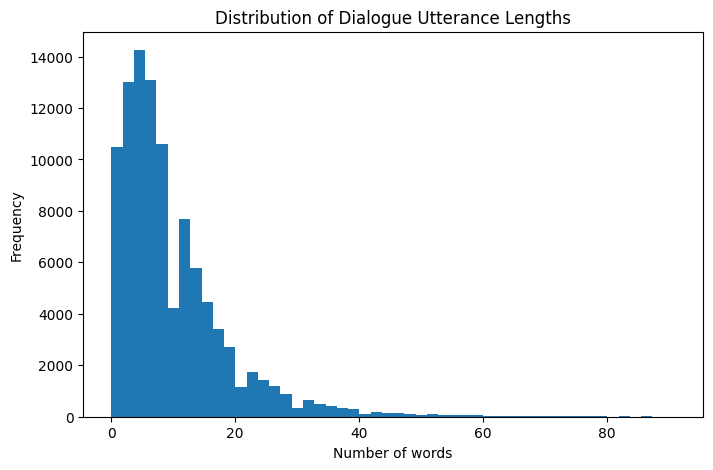

In [16]:
plt.figure(figsize=(8, 5))
plt.hist(df["text_length"], bins=50)
plt.title("Distribution of Dialogue Utterance Lengths")
plt.xlabel("Number of words")
plt.ylabel("Frequency")
plt.show()

Step 16: Inspect very long utterances:

The longest dialogue utterances are inspected to identify possible outliers that may need to be truncated or removed during preprocessing.

In [17]:
df.nlargest(10, "text_length")[[TEXT_COLUMN, "text_length"]]

,text,text_length
7872964,I'm glad you bed to differ but you cannot save...,91
22382402,i installed the ubuntu only on a single partit...,89
7773455,as gonna say thati was gonna say thati was gon...,89
13082187,"I've got a small problem, and i dont know near...",89
13757743,"Hi, I am having a problem mounting a partition...",88
15599745,"My computer has been randomly turning off, at ...",88
19071376,Does anyone know where I can get help with thi...,88
18800196,I need some help over the automatic shambles u...,87
25951253,"hi, can anyone help me please, i have DL a mov...",87
15170184,Well if you think of the package that would be...,86


Spet 17: Filter very long and empty utterances:

Dialogue utterances longer than the selected maximum length are removed. Limiting sequence length reduces computational complexity and improves training efficiency.

In [18]:
MAX_LENGTH = 30

filtered_df = df[
    (df["text_length"] > 0) &
    (df["text_length"] <= MAX_LENGTH)
].copy()

print("Original dataset size:", len(df))
print("Filtered dataset size:", len(filtered_df))
print("Rows removed:", len(df) - len(filtered_df))

Original dataset size: 99992
Filtered dataset size: 94868
Rows removed: 5124


Step 18: Plot filtered lenght distribution:

he distribution of dialogue lengths is plotted again after filtering to verify that extremely long utterances have been removed successfully.

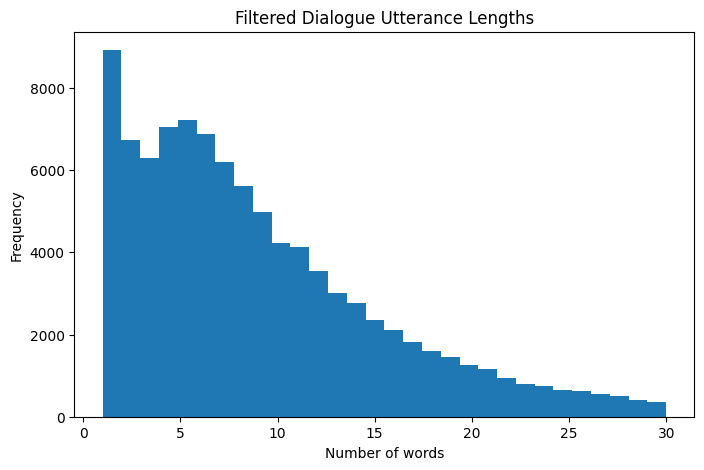

In [19]:
plt.figure(figsize=(8, 5))
plt.hist(filtered_df["text_length"], bins=30)
plt.title("Filtered Dialogue Utterance Lengths")
plt.xlabel("Number of words")
plt.ylabel("Frequency")
plt.show()

Step 19: Vocabulary analysis:

All dialogue text is combined to calculate the overall vocabulary size. The vocabulary represents the number of unique words present in the dataset and provides an indication of model complexity.

In [20]:
words = []

for text in filtered_df["text_clean"].astype(str):
    words.extend(text.split())

vocab_counter = Counter(words)
vocab_size = len(vocab_counter)

print("Total tokens:", len(words))
print("Vocabulary size:", vocab_size)


Total tokens: 834722
Vocabulary size: 37819


Step 20 : Top 20 most frequent words:

The twenty most frequently occurring words are identified. This provides insight into the language used throughout the Ubuntu Dialogue Corpus.

In [21]:
top_words_df = pd.DataFrame(
    vocab_counter.most_common(20),
    columns=["Word", "Frequency"]
)

top_words_df

,Word,Frequency
0,i,29339
1,the,28126
2,to,23572
3,it,18428
4,you,17373
5,a,16682
6,is,14392
7,and,12016
8,that,10175
9,in,9463


Step 21: Plot top 20 words:

A bar chart is used to visualise the twenty most frequent words identified in the previous step.



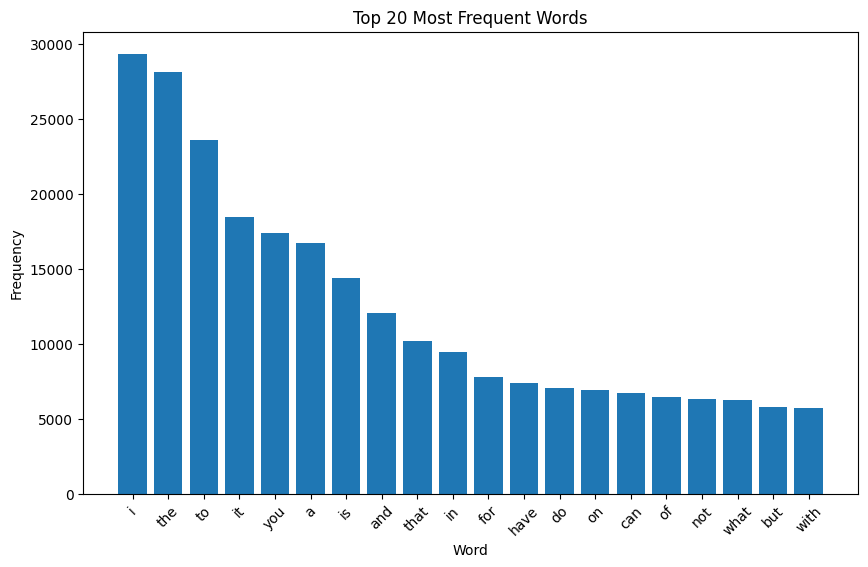

In [22]:
plt.figure(figsize=(10, 6))
plt.bar(top_words_df["Word"], top_words_df["Frequency"])
plt.title("Top 20 Most Frequent Words")
plt.xlabel("Word")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.show()

Step 22: Rare words analysis:

Rare words are words that appear only once within the dataset. Identifying rare words helps determine whether they should be replaced by an `<UNK>` token during preprocessing to reduce vocabulary size.

In [23]:
rare_words = [word for word, count in vocab_counter.items() if count == 1]

print("Vocabulary size:", vocab_size)
print("Rare words:", len(rare_words))
print("Percentage of vocabulary:",
      round((len(rare_words)/vocab_size)*100,2), "%")

Vocabulary size: 37819
Rare words: 24751
Percentage of vocabulary: 65.45 %


Step 23: Display some rare words:

Rare words are words that appear only once within the dataset. Identifying rare words helps determine whether they should be replaced by an `<UNK>` token during preprocessing to reduce vocabulary size.

In [24]:
print("Examples of rare words:")

rare_words[:30]

Examples of rare words:


['alternitive',
 'privmsg',
 'staunch',
 'areckx',
 'arthurarchnix',
 'jexmex',
 'anythingl',
 'initiald',
 'ntf',
 'gspca',
 'neurotically',
 '9339',
 '2840',
 '1492',
 '0105',
 '340',
 'usrlibgamingam_server',
 'mep',
 'btwcase',
 '35usd',
 'fiestyfawn',
 'performanceuse',
 'dacomp',
 'nstuff',
 'tj',
 'moderately',
 'usally',
 'windowdrives',
 'libid3tag0',
 '0151b']

Step 24: Tokenisation:

Tokenisation is the process of splitting a sentence into smaller units called **tokens**, which are typically individual words or subword units. It is one of the fundamental preprocessing steps in Natural Language Processing (NLP).

Machine learning models cannot process raw text directly. Therefore, each dialogue utterance must first be tokenised before the tokens are converted into numerical representations (such as integer sequences or embeddings) that can be used as input to a neural network.



In [25]:
sample_text = filtered_df["text_clean"].iloc[0]

print("Original sentence:\n")
print(sample_text)

tokens = sample_text.split()

print("\nTokenised sentence:\n")
print(tokens)

print("\nNumber of tokens:", len(tokens))

Original sentence:

etc

Tokenised sentence:

['etc']

Number of tokens: 1


Step 27: Vocabulary Statistics:

Additional vocabulary statistics are presented, including the total number of unique words and average dialogue length. These statistics help estimate the complexity of the dataset.

In [26]:
average_words = filtered_df["text_length"].mean()

print(f"Average dialogue length: {average_words:.2f} words")
print(f"Shortest dialogue: {filtered_df['text_length'].min()} words")
print(f"Longest dialogue: {filtered_df['text_length'].max()} words")
print(f"Vocabulary size: {vocab_size}")

Average dialogue length: 8.80 words
Shortest dialogue: 1 words
Longest dialogue: 30 words
Vocabulary size: 37819


Step 28: Preprocessing Recomendations:

Based on the exploratory analysis, several preprocessing steps are recommended before training the chatbot models. These recommendations are intended to improve data quality and reduce model complexity.


- Remove duplicate dialogue records.
- Remove rows containing missing dialogue text.
- Convert all dialogue text to lowercase.
- Remove punctuation and unnecessary whitespace.
- Tokenise dialogue text into individual words.
- Replace rare words with the `<UNK>` token.
- Limit dialogue length to approximately 30 words.
- Convert text into integer sequences.
- Pad sequences to equal length before model training.
- Add `<START>` and `<END>` tokens to decoder responses.

Step 29: EDA Summary :


The Ubuntu Dialogue Corpus was analysed to assess its suitability for developing a generative chatbot using Seq2Seq models.

The dataset consists of conversational dialogue extracted from Ubuntu IRC support channels. Data quality analysis showed that missing values and duplicate records can be removed with minimal impact on the dataset. Dialogue length analysis indicated that most utterances are relatively short, while a small number of very long utterances may need to be filtered before model training.

Vocabulary analysis showed a large number of unique words, including many rare terms that occur only once. Replacing infrequent words with an `<UNK>` token is therefore recommended to reduce model complexity.

Overall, the dataset is suitable for chatbot development following standard NLP preprocessing techniques such as text cleaning, tokenisation, vocabulary reduction, sequence padding, and train/validation/test splitting.